# Lab RL \# 2

En el siguiente laboratorio, los estudiantes deben:
- aprender a utilizar StableBaselines3 para importar un algoritmo de Deep RL
- implementar loops de entrenamiento con StableBaselines y entornos de Gym
- optimizar los hiperparámetros de estos algoritmos
- comparar diferentes algoritmos
- entender los desafíos de la función de recompensa en RL

Los estudiantes pueden entregar una copia de este Notebook y, si necesario, un informe en formato .pdf.

# StableBaselines

StableBaselines3 (SB3) es una biblioteca en Python, basada en PyTorch, que proporciona implementaciones estables, modulares y reproducibles de algoritmos estándar de Deep Reinforcement Learning.

([Más detalles](https://github.com/DLR-RM/stable-baselines3))

Está diseñada para entrenar agentes sobre entornos compatibles con la API de Gymnasium.

SB3 incluye implementaciones ready-to-use de algoritmos on-policy y off-policy, como PPO, A2C, DQN, SAC y TD3, con abstracciones claras para políticas, buffers de experiencia, entornos vectorizados y callbacks.

La biblioteca permite:
- entrenar agentes directamente sobre entornos de Gymnasium (incluyendo entornos personalizados);
- guardar y cargar modelos entrenados de forma reproducible;
- monitorear el aprendizaje (rewards, longitudes de episodios, etc.);
- optimizar hiperparámetros (tasa de aprendizaje, tamaño de red, coeficientes de entropía, etc.).

Stable-Baselines3 separa claramente la definición del entorno, la arquitectura de la política y el algoritmo de aprendizaje, lo que facilita la experimentación y la comparación de métodos.

### Entornos vectorizados y `n_envs`

SB3 permite entrenar con múltiples instancias del entorno corriendo en paralelo mediante `make_vec_env`. Esto reduce el tiempo de entrenamiento al recolectar experiencias de varios entornos simultáneamente:

```python
from stable_baselines3.common.env_util import make_vec_env
env = make_vec_env("CartPole-v1", n_envs=4)
model = PPO("MlpPolicy", env, verbose=1)
```

Nota: `total_timesteps` cuenta el total de pasos **a través de todos los entornos**, por lo que las comparaciones de eficiencia de muestras siguen siendo justas. Los algoritmos on-policy como PPO se benefician más de `n_envs` (la recolección de rollouts es el cuello de botella); los off-policy como SAC y DDPG se benefician menos en entornos simples (el cuello de botella es la actualización del gradiente).

## Ejemplo básico
En este ejemplo, SB3 es utilizado para importar y entrenar PPO sobre CartPole.

In [21]:
!apt-get update && apt-get install -y ffmpeg freeglut3-dev xvfb  # Para visualización
!pip install "stable-baselines3[extra]>=2.0.0a4"

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

env = make_vec_env("CartPole-v1", n_envs=4)
model = PPO("MlpPolicy", env, verbose=1)

print("Entrenando...")
model.learn(total_timesteps=10_000)
print("Listo.")

Using cpu device
Entrenando...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.4     |
|    ep_rew_mean     | 20.4     |
| time/              |          |
|    fps             | 5614     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 34.2        |
|    ep_rew_mean          | 34.2        |
| time/                   |             |
|    fps                  | 1831        |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.013741916 |
|    clip_fraction        | 0.216       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.682      |
|    explained_variance   | 0.00579     |

StableBaseline propone otros [Google Colab Notebooks](https://github.com/Stable-Baselines-Team/rl-colab-notebooks/tree/sb3?tab=readme-ov-file) para aprender a utilizar la biblioteca (especialmente *Getting Started*, *Saving & Loading* y *Monitor Training*).

También les recomiendo revisar los [EvalCallbacks](https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html): permiten evaluar al agente en modo explotación durante el entrenamiento para conocer su desempeño real.

# Ejercicio 1 (16 puntos)

- Entrenen con SB3 3 algoritmos: PPO, SAC y DDPG sobre el entorno [Pendulum](https://gymnasium.farama.org/environments/classic_control/pendulum/) de Gymnasium.

- Para cada algoritmo, prueben las siguientes combinaciones de hiperparámetros (4 puntos por algoritmo):
  - PPO:
    - learning_rate (1e-4, 1e-3)
    - clip_range (0.1, 0.3)
  - SAC:
    - learning_rate (1e-4, 1e-3)
    - batch_size (64, 128)
  - DDPG:
    - learning_rate (1e-4, 1e-3)
    - batch_size (64, 128)

  Las dimensiones de las redes neuronales pueden fijarse a [128, 128].

- Para cada algoritmo, con los mejores hiperparámetros, entrenen tres veces con distintas semillas aleatorias y tracen en un mismo gráfico las tres curvas de aprendizaje (retorno por episodio).

Pregunta 1 (2 puntos): Describan el efecto de cada hiperparámetro sobre el comportamiento y el rendimiento de los algoritmos.

Pregunta 2 (1 punto): ¿Qué algoritmo obtiene el mejor rendimiento en el entorno Pendulum?

Pregunta 3 (1 punto): ¿Existen variaciones entre las diferentes curvas entrenadas con el mismo algoritmo, el mismo entorno y los mismos hiperparámetros? ¿Por qué?

In [23]:
from stable_baselines3 import PPO, SAC, DDPG
from stable_baselines3.common.env_util import make_vec_env
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# Función para evaluar un modelo
def evaluate_model(model, env_id="Pendulum-v1", num_episodes=10):
    """Evalúa el modelo y retorna el retorno promedio."""
    env = gym.make(env_id)
    returns = []
    for _ in range(num_episodes):
        obs, _ = env.reset()
        episode_return = 0
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            episode_return += reward
            done = terminated or truncated
        returns.append(episode_return)
    env.close()
    return np.mean(returns)

In [25]:
# Definir hiperparámetros a probar
ppo_params = [
    {"learning_rate": 1e-4, "clip_range": 0.1},
    {"learning_rate": 1e-4, "clip_range": 0.3},
    {"learning_rate": 1e-3, "clip_range": 0.1},
    {"learning_rate": 1e-3, "clip_range": 0.3},
]

sac_params = [
    {"learning_rate": 1e-4, "batch_size": 64},
    {"learning_rate": 1e-4, "batch_size": 128},
    {"learning_rate": 1e-3, "batch_size": 64},
    {"learning_rate": 1e-3, "batch_size": 128},
]

ddpg_params = [
    {"learning_rate": 1e-4, "batch_size": 64},
    {"learning_rate": 1e-4, "batch_size": 128},
    {"learning_rate": 1e-3, "batch_size": 64},
    {"learning_rate": 1e-3, "batch_size": 128},
]

# Configuración común
TIMESTEPS = 100_000
EVAL_EPISODES = 10
policy_kwargs = {"net_arch": [128, 128]}

In [26]:
# ==========================================
# ENTRENAMIENTO PPO
# ==========================================
print("\n" + "="*50)
print("ENTRENANDO PPO")
print("="*50)

ppo_results = {}
for i, params in enumerate(ppo_params):
    print(f"\nIntento {i+1}/4: learning_rate={params['learning_rate']}, "
          f"clip_range={params['clip_range']}")
    
    env = make_vec_env("Pendulum-v1", n_envs=4)
    model = PPO("MlpPolicy", env, policy_kwargs=policy_kwargs, **params, verbose=0)
    model.learn(total_timesteps=TIMESTEPS)
    
    mean_reward = evaluate_model(model, num_episodes=EVAL_EPISODES)
    ppo_results[str(params)] = mean_reward
    print(f"  → Retorno promedio: {mean_reward:.2f}")
    env.close()

# Mejores parámetros para PPO
best_ppo_params = max(ppo_results, key=ppo_results.get)
print(f"\n✓ Mejores parámetros PPO: {best_ppo_params}")
print(f"  Retorno: {ppo_results[best_ppo_params]:.2f}")


ENTRENANDO PPO

Intento 1/4: learning_rate=0.0001, clip_range=0.1
  → Retorno promedio: -1261.63

Intento 2/4: learning_rate=0.0001, clip_range=0.3
  → Retorno promedio: -1244.59

Intento 3/4: learning_rate=0.001, clip_range=0.1
  → Retorno promedio: -808.61

Intento 4/4: learning_rate=0.001, clip_range=0.3
  → Retorno promedio: -185.88

✓ Mejores parámetros PPO: {'learning_rate': 0.001, 'clip_range': 0.3}
  Retorno: -185.88


In [27]:
# ==========================================
# ENTRENAMIENTO SAC
# ==========================================
print("\n" + "="*50)
print("ENTRENANDO SAC")
print("="*50)

sac_results = {}
for i, params in enumerate(sac_params):
    print(f"\nIntento {i+1}/4: learning_rate={params['learning_rate']}, "
          f"batch_size={params['batch_size']}")
    
    env = gym.make("Pendulum-v1")
    model = SAC("MlpPolicy", env, policy_kwargs=policy_kwargs, **params, verbose=0)
    model.learn(total_timesteps=TIMESTEPS)
    
    mean_reward = evaluate_model(model, num_episodes=EVAL_EPISODES)
    sac_results[str(params)] = mean_reward
    print(f"  → Retorno promedio: {mean_reward:.2f}")
    env.close()

# Mejores parámetros para SAC
best_sac_params = max(sac_results, key=sac_results.get)
print(f"\n✓ Mejores parámetros SAC: {best_sac_params}")
print(f"  Retorno: {sac_results[best_sac_params]:.2f}")



ENTRENANDO SAC

Intento 1/4: learning_rate=0.0001, batch_size=64
  → Retorno promedio: -165.04

Intento 2/4: learning_rate=0.0001, batch_size=128
  → Retorno promedio: -140.08

Intento 3/4: learning_rate=0.001, batch_size=64
  → Retorno promedio: -138.38

Intento 4/4: learning_rate=0.001, batch_size=128
  → Retorno promedio: -99.54

✓ Mejores parámetros SAC: {'learning_rate': 0.001, 'batch_size': 128}
  Retorno: -99.54


In [28]:
# ==========================================
# ENTRENAMIENTO DDPG
# ==========================================
print("\n" + "="*50)
print("ENTRENANDO DDPG")
print("="*50)

# DDPG requiere arquitectura diferente: pi y qf por separado
ddpg_policy_kwargs = {"net_arch": {"pi": [128, 128], "qf": [128, 128]}}

ddpg_results = {}
for i, params in enumerate(ddpg_params):
    print(f"\nIntento {i+1}/4: learning_rate={params['learning_rate']}, "
          f"batch_size={params['batch_size']}")
    
    env = gym.make("Pendulum-v1")
    model = DDPG("MlpPolicy", env, policy_kwargs=ddpg_policy_kwargs, **params, verbose=0)
    model.learn(total_timesteps=TIMESTEPS)
    
    mean_reward = evaluate_model(model, num_episodes=EVAL_EPISODES)
    ddpg_results[str(params)] = mean_reward
    print(f"  → Retorno promedio: {mean_reward:.2f}")
    env.close()

# Mejores parámetros para DDPG
best_ddpg_params = max(ddpg_results, key=ddpg_results.get)
print(f"\n✓ Mejores parámetros DDPG: {best_ddpg_params}")
print(f"  Retorno: {ddpg_results[best_ddpg_params]:.2f}")



ENTRENANDO DDPG

Intento 1/4: learning_rate=0.0001, batch_size=64
  → Retorno promedio: -144.61

Intento 2/4: learning_rate=0.0001, batch_size=128
  → Retorno promedio: -133.59

Intento 3/4: learning_rate=0.001, batch_size=64
  → Retorno promedio: -145.41

Intento 4/4: learning_rate=0.001, batch_size=128
  → Retorno promedio: -155.41

✓ Mejores parámetros DDPG: {'learning_rate': 0.0001, 'batch_size': 128}
  Retorno: -133.59


In [29]:
# ==========================================
# ENTRENAMIENTOS CON 3 SEMILLAS (MEJORES PARÁMETROS)
# ==========================================
print("\n" + "="*50)
print("ENTRENAMIENTOS CON 3 SEMILLAS (MEJORES PARÁMETROS)")
print("="*50)

SEEDS = [1, 2, 3]
ppo_curves = []
sac_curves = []
ddpg_curves = []

# PPO con mejores parámetros
best_ppo_dict = eval(best_ppo_params)
# Crear un diccionario policy_kwargs modificado para PPO para evitar el conflicto con 'use_sde'
ppo_specific_policy_kwargs = policy_kwargs.copy()
if 'use_sde' in ppo_specific_policy_kwargs:
    del ppo_specific_policy_kwargs['use_sde']

for seed in SEEDS:
    print(f"\nPPO - seed={seed}")
    env = make_vec_env("Pendulum-v1", n_envs=4)
    model = PPO("MlpPolicy", env, seed=seed, policy_kwargs=ppo_specific_policy_kwargs,
                **best_ppo_dict, verbose=0)

    # Recolectar retornos durante el entrenamiento
    returns = []
    for i in range(0, TIMESTEPS, 1000):
        model.learn(total_timesteps=1000, reset_num_timesteps=False)
        mean_reward = evaluate_model(model, num_episodes=5)
        returns.append(mean_reward)

    ppo_curves.append(returns)
    env.close()

# SAC con mejores parámetros
best_sac_dict = eval(best_sac_params)
# Crear un diccionario policy_kwargs modificado para SAC para evitar el conflicto con 'use_sde'
sac_specific_policy_kwargs = policy_kwargs.copy()
if 'use_sde' in sac_specific_policy_kwargs:
    del sac_specific_policy_kwargs['use_sde']

for seed in SEEDS:
    print(f"\nSAC - seed={seed}")
    env = gym.make("Pendulum-v1")
    model = SAC("MlpPolicy", env, seed=seed, policy_kwargs=sac_specific_policy_kwargs,
                **best_sac_dict, verbose=0)

    returns = []
    for i in range(0, TIMESTEPS, 1000):
        model.learn(total_timesteps=1000, reset_num_timesteps=False)
        mean_reward = evaluate_model(model, num_episodes=5)
        returns.append(mean_reward)

    sac_curves.append(returns)
    env.close()

# DDPG con mejores parámetros (usar ddpg_policy_kwargs)
best_ddpg_dict = eval(best_ddpg_params)
for seed in SEEDS:
    print(f"\nDDPG - seed={seed}")
    env = gym.make("Pendulum-v1")
    model = DDPG("MlpPolicy", env, seed=seed, policy_kwargs=ddpg_policy_kwargs,
                 **best_ddpg_dict, verbose=0)

    returns = []
    for i in range(0, TIMESTEPS, 1000):
        model.learn(total_timesteps=1000, reset_num_timesteps=False)
        mean_reward = evaluate_model(model, num_episodes=5)
        returns.append(mean_reward)

    ddpg_curves.append(returns)
    env.close()


ENTRENAMIENTOS CON 3 SEMILLAS (MEJORES PARÁMETROS)

PPO - seed=1

PPO - seed=2

PPO - seed=3

SAC - seed=1

SAC - seed=2

SAC - seed=3

DDPG - seed=1

DDPG - seed=2

DDPG - seed=3


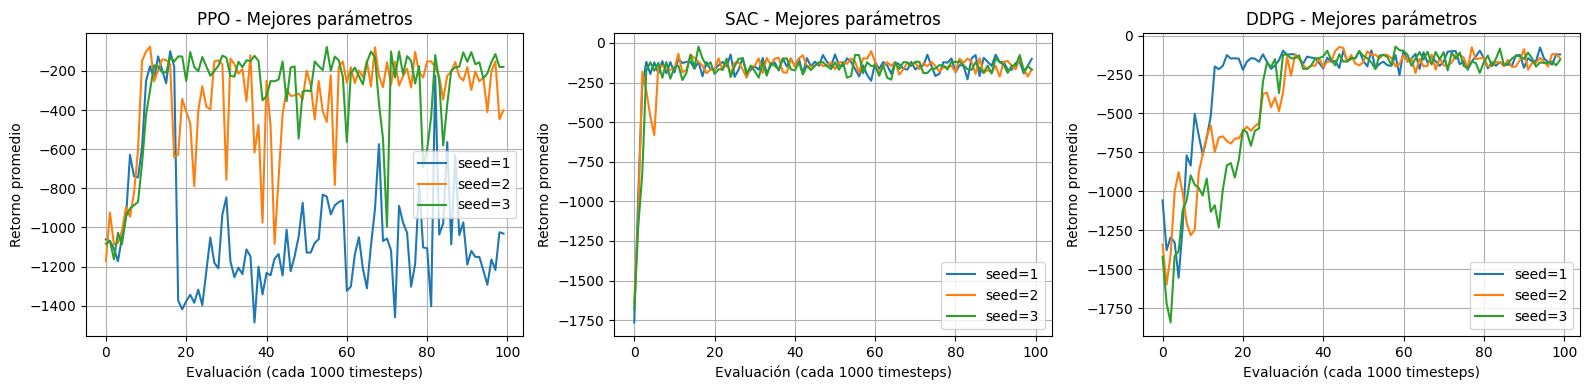


RESUMEN EJERCICIO 1

Mejores parámetros:
  PPO:  {'learning_rate': 0.001, 'clip_range': 0.3}
  SAC:  {'learning_rate': 0.001, 'batch_size': 128}
  DDPG: {'learning_rate': 0.0001, 'batch_size': 128}


In [30]:
# ==========================================
# GRÁFICOS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# PPO
colors = ["tab:blue", "tab:orange", "tab:green"]
for i, curve in enumerate(ppo_curves):
    axes[0].plot(curve, color=colors[i], label=f"seed={SEEDS[i]}")
axes[0].set_title("PPO - Mejores parámetros")
axes[0].set_xlabel("Evaluación (cada 1000 timesteps)")
axes[0].set_ylabel("Retorno promedio")
axes[0].legend()
axes[0].grid()

# SAC
for i, curve in enumerate(sac_curves):
    axes[1].plot(curve, color=colors[i], label=f"seed={SEEDS[i]}")
axes[1].set_title("SAC - Mejores parámetros")
axes[1].set_xlabel("Evaluación (cada 1000 timesteps)")
axes[1].set_ylabel("Retorno promedio")
axes[1].legend()
axes[1].grid()

# DDPG
for i, curve in enumerate(ddpg_curves):
    axes[2].plot(curve, color=colors[i], label=f"seed={SEEDS[i]}")
axes[2].set_title("DDPG - Mejores parámetros")
axes[2].set_xlabel("Evaluación (cada 1000 timesteps)")
axes[2].set_ylabel("Retorno promedio")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

# ==========================================
# RESUMEN
# ==========================================
print("\n" + "="*50)
print("RESUMEN EJERCICIO 1")
print("="*50)
print(f"\nMejores parámetros:")
print(f"  PPO:  {best_ppo_params}")
print(f"  SAC:  {best_sac_params}")
print(f"  DDPG: {best_ddpg_params}")

# Ejercicio 2 (9 puntos)

**Objetivo**: Explorar cómo la estructura de la recompensa puede dificultar el aprendizaje, y cómo el *reward shaping* puede guiar al agente cuando la recompensa original genera mínimos locales problemáticos.

### El entorno: MountainCarContinuous-v0

Un carro debe escalar una colina empinada. No tiene suficiente potencia para subir directamente — debe oscilar hacia atrás y adelante para acumular momentum.

| | |
|---|---|
| **Observación** | `[posición, velocidad]`, posición ∈ [-1.2, 0.6] |
| **Acción** | Fuerza continua ∈ [-1, 1] |
| **Recompensa** | -0.1 × acción² por paso (penalidad de energía) + 100 al llegar al objetivo |
| **Objetivo** | Posición ≥ 0.45 |

### Helper functions

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt


class EpisodeTracker(BaseCallback):
    """Registra el retorno de cada episodio durante el entrenamiento."""
    def __init__(self, print_freq=20):
        super().__init__()
        self.ep_rewards = []           # recompensa con shaping (lo que PPO optimiza)
        self.ep_original_rewards = []  # recompensa original del entorno
        self.print_freq = print_freq

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
            if "original_ep_reward" in info:
                self.ep_original_rewards.append(info["original_ep_reward"])

        if self.print_freq:
            n = len(self.ep_rewards)
            if n > 0 and n % self.print_freq == 0:
                shaped_mean = np.mean(self.ep_rewards[-self.print_freq:])
                if self.ep_original_rewards and len(self.ep_original_rewards) >= self.print_freq:
                    orig_mean = np.mean(self.ep_original_rewards[-self.print_freq:])
                    print(f"  ep {n:4d} | steps {self.num_timesteps:7,d} | "
                          f"shaped: {shaped_mean:7.1f} | orig: {orig_mean:7.1f}")
                else:
                    print(f"  ep {n:4d} | steps {self.num_timesteps:7,d} | "
                          f"reward: {shaped_mean:7.1f}")
        return True


def plot_curve(rewards, label, color, ax, window=20, show_goal=True):
    ax.plot(rewards, alpha=0.3, color=color)
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode="valid")
        ax.plot(smoothed, color=color, linewidth=2, label=label)
    else:
        ax.plot(rewards, color=color, linewidth=2, label=label)
    if show_goal:
        ax.axhline(90, color="green", linestyle="--", linewidth=0.8, label="Objetivo (≥ 90)")
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Retorno")
    ax.legend()


def train(env_shaped, seed=42, timesteps=400_000, show_curves=True):
    """Entrena PPO con el entorno dado y devuelve el modelo entrenado.

    El modelo tiene un atributo model.tracker con las recompensas por episodio.
    Si show_curves=True (por defecto), muestra las curvas automáticamente:
      - Sin wrapper (Paso 1): un solo panel con la recompensa del entorno.
      - Con wrapper (Paso 2): dos paneles — recompensa con shaping y recompensa original
        comparada con el Paso 1.
    """
    model = PPO("MlpPolicy", env_shaped, seed=seed, device="cpu", verbose=0)
    tracker = EpisodeTracker()
    print(f"Entrenando PPO (seed={seed}, {timesteps:,} timesteps)...")
    model.learn(total_timesteps=timesteps, callback=tracker)
    model.tracker = tracker

    if show_curves:
        has_shaping = bool(tracker.ep_original_rewards)
        baseline = globals().get("tracker_base")

        if has_shaping and baseline:
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            plot_curve(tracker.ep_rewards, "con shaping", "tab:orange", axes[0], show_goal=False)
            axes[0].set_title("Recompensa con shaping (señal de aprendizaje)")
            plot_curve(baseline.ep_rewards, "sin shaping (Paso 1)", "tab:blue", axes[1])
            plot_curve(tracker.ep_original_rewards, "con shaping", "tab:orange", axes[1])
            axes[1].set_title("Recompensa original (desempeño real)")
        else:
            fig, ax = plt.subplots(figsize=(10, 4))
            plot_curve(tracker.ep_rewards, "PPO sin shaping", "tab:blue", ax)
            ax.set_title("MountainCarContinuous — PPO sin reward shaping")

        plt.tight_layout()
        plt.show()

        to_report = tracker.ep_original_rewards if has_shaping else tracker.ep_rewards
        if to_report:
            print(f"Recompensa original — últimos 20 eps: {np.mean(to_report[-20:]):.1f} | "
                  f"mejor: {max(to_report):.1f} | "
                  f"{'Sí ✓' if max(to_report) > 90 else 'No ✗'}")

    return model


def plot_trajectories(model, title="Trayectorias del agente", n_episodes=5):
    """Ejecuta n_episodes en modo determinístico y grafica posición, velocidad y acción."""
    eval_env = gym.make("MountainCarContinuous-v0")
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
    colors = plt.cm.tab10.colors

    for ep in range(n_episodes):
        obs, _ = eval_env.reset()
        positions, velocities, actions = [], [], []
        done = False
        reached_goal = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            actions.append(action.item())
            obs, _, terminated, truncated, _ = eval_env.step(action)
            positions.append(obs[0])
            velocities.append(obs[1])
            done = terminated or truncated
            if terminated and obs[0] >= 0.45:
                reached_goal = True

        orig_r = sum(-0.1 * a**2 for a in actions) + (100 if reached_goal else 0)
        label = f"ep {ep+1} (orig≈{orig_r:.0f}, {'llegó ✓' if reached_goal else 'no llegó'})"
        t = range(len(positions))
        axes[0].plot(t, positions,  color=colors[ep], label=label)
        axes[1].plot(t, velocities, color=colors[ep])
        axes[2].plot(t, actions,    color=colors[ep], alpha=0.8)

    axes[0].axhline(0.45, color="black", linestyle="--", lw=1, label="Objetivo (pos=0.45)")
    axes[0].axhline(-0.6, color="gray",  linestyle=":",  lw=0.8, label="Inicio (~-0.6)")
    axes[0].set_ylabel("Posición")
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color="gray", linestyle=":", lw=0.8)
    axes[1].set_ylabel("Velocidad")
    axes[2].axhline(0, color="gray", linestyle=":", lw=0.8)
    axes[2].set_ylabel("Acción")
    axes[2].set_xlabel("Paso")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    eval_env.close()


def show_animation(model, title="Política aprendida (modo determinístico)"):
    """Renderiza un episodio completo y lo devuelve como animación embebida."""
    from matplotlib import animation
    from IPython.display import HTML

    env_render = gym.make("MountainCarContinuous-v0", render_mode="rgb_array")
    obs, _ = env_render.reset()
    frames = []
    done = False
    while not done:
        frames.append(env_render.render())
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env_render.step(action)
        done = terminated or truncated
    env_render.close()

    fig, ax = plt.subplots(figsize=(6, 4))
    img = ax.imshow(frames[0])
    ax.axis("off")
    ax.set_title(title)

    def update(frame):
        img.set_data(frame)
        return [img]

    ani = animation.FuncAnimation(fig, update, frames=frames[::2], interval=40, blit=True)
    plt.close()
    return HTML(ani.to_jshtml())

### Paso 1 (3 puntos)

Ejecuten el código de entrenamiento a continuación: PPO sobre `MountainCarContinuous-v0` con hiperparámetros por defecto durante 400,000 timesteps.

**Preguntas:**

1. ¿Qué observan en la curva de aprendizaje? ¿Logra el agente llegar al objetivo? (1 punto)
2. ¿Por qué PPO converge a este comportamiento? ¿Cuál es el mínimo local que encuentra, y qué propiedad de la función de recompensa lo facilita? (2 puntos)

In [ ]:
ppo_base = train(gym.make("MountainCarContinuous-v0"), timesteps=400_000)
tracker_base = ppo_base.tracker

Entrenando PPO (seed=42, 400,000 timesteps)...
  ep   20 | steps  19,980 | reward:   -35.2
  ep   20 | steps  19,981 | reward:   -35.2
  ep   20 | steps  19,982 | reward:   -35.2
  ep   20 | steps  19,983 | reward:   -35.2
  ep   20 | steps  19,984 | reward:   -35.2
  ep   20 | steps  19,985 | reward:   -35.2
  ep   20 | steps  19,986 | reward:   -35.2
  ep   20 | steps  19,987 | reward:   -35.2
  ep   20 | steps  19,988 | reward:   -35.2
  ep   20 | steps  19,989 | reward:   -35.2
  ep   20 | steps  19,990 | reward:   -35.2
  ep   20 | steps  19,991 | reward:   -35.2
  ep   20 | steps  19,992 | reward:   -35.2
  ep   20 | steps  19,993 | reward:   -35.2
  ep   20 | steps  19,994 | reward:   -35.2
  ep   20 | steps  19,995 | reward:   -35.2
  ep   20 | steps  19,996 | reward:   -35.2
  ep   20 | steps  19,997 | reward:   -35.2
  ep   20 | steps  19,998 | reward:   -35.2
  ep   20 | steps  19,999 | reward:   -35.2
  ep   20 | steps  20,000 | reward:   -35.2
  ep   20 | steps  20,001 | r

In [ ]:
# ==========================================
# EJERCICIO 2 - PASO 1
# Entrenar PPO sin Reward Shaping
# ==========================================

print("\n" + "="*60)
print("PASO 1: Entrenamiento sin Reward Shaping")
print("="*60)

# Crear el entorno y entrenar PPO con hiperparámetros por defecto
print("\nEntrenando PPO sobre MountainCarContinuous-v0...")
print("Duración: 400,000 timesteps")
print("Hiperparámetros: por defecto\n")

ppo_base = train(gym.make("MountainCarContinuous-v0"), timesteps=400_000)
tracker_base = ppo_base.tracker

print("\n✓ Entrenamiento completado")

In [ ]:
show_animation(ppo_base, "Política aprendida — Paso 1 (modo determinístico)")

In [ ]:
plot_trajectories(ppo_base, "Trayectorias del agente — Paso 1 (modo determinístico)")

## Reward Shaping

El *reward shaping* consiste en agregar una señal auxiliar a la recompensa original para guiar al agente durante el aprendizaje:

$$r'(s, a, s') = r(s, a, s') + F(s, s')$$

donde $F$ es la función de shaping que ustedes diseñan. El objetivo es facilitar la exploración o guiar al agente hacia regiones del espacio de estados relevantes.

### Cómo implementarlo en Gymnasium

Un `gym.Wrapper` intercepta las llamadas al entorno y permite modificar observaciones, acciones o recompensas. Para modificar la recompensa, sobreescribimos `step()`:

```python
class MiWrapper(gym.Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # modificar reward aquí usando obs
        return obs, nueva_reward, terminated, truncated, info
```

En `MountainCarContinuous-v0`, la observación es `obs = [posición, velocidad]`:
- **posición** ∈ [-1.2, 0.6] — el objetivo está en posición ≥ 0.45
- **velocidad** ∈ [-0.07, 0.07]

In [ ]:
class MountainCarShapingWrapper(gym.Wrapper):
    """
    Wrapper de reward shaping para MountainCarContinuous-v0.

    Recibe una función de shaping con la firma:
        shaping_fn(position, velocity) -> float
    donde:
        posición ∈ [-1.2, 0.6]  →  objetivo: posición ≥ 0.45
        velocidad ∈ [-0.07, 0.07]

    Nota: como el episodio termina en cuanto position ≥ 0.45, pueden implementar
    un bonus de llegada comprobando directamente esa condición en su función.

    El wrapper también acumula la recompensa original por episodio y la guarda en
    info["original_ep_reward"] para que train() pueda trazarla automáticamente.
    """
    def __init__(self, env, shaping_fn):
        super().__init__(env)
        self.shaping_fn = shaping_fn

    def reset(self, **kwargs):
        self._ep_original_reward = 0.0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        position, velocity = obs
        self._ep_original_reward += reward
        if terminated or truncated:
            info["original_ep_reward"] = self._ep_original_reward
            self._ep_original_reward = 0.0
        shaping = self.shaping_fn(position, velocity)
        return obs, reward + shaping, terminated, truncated, info

### Paso 2 (6 puntos)

El reward shaping es un proceso de **diseño iterativo**. Es normal que las primeras funciones que prueben no funcionen bien — eso es parte del ejercicio. El objetivo no es solo encontrar una función que funcione, sino **documentar el proceso de exploración y razonamiento** que los llevó hasta ella.

**Flujo de trabajo (repitan para cada intento):**

1. En la celda de entrenamiento, definan una función `mi_shaping(position, velocity)` con su idea.
2. Llamen `train(env)` — entrena PPO y muestra automáticamente las dos curvas (recompensa con shaping y recompensa original).
3. Ejecuten `show_animation(model, ...)` y `plot_trajectories(model, ...)` para ver el comportamiento del agente.
4. Analicen: ¿qué comportamiento indujo el shaping? ¿Por qué funcionó o falló?
5. Modifiquen la función y repitan.

Una vez que encuentren una función que funcione, entrenen con **3 semillas distintas** usando la celda de múltiples semillas.

**Preguntas:**

1. (4 puntos) Para **cada intento** realizado, reporten:
   - La fórmula de shaping que probaron.
   - El razonamiento: ¿por qué pensaron que guiaría al agente hacia el objetivo?
   - Lo que observaron: curvas de aprendizaje y trayectorias del agente.
   - La conclusión: ¿qué comportamiento indujo el shaping? ¿Por qué funcionó o falló?
   - Si no funcionó: ¿qué decidieron cambiar y por qué?

2. (2 puntos) Muestren las curvas de recompensa original con 3 semillas para su función de shaping final. ¿El agente llega al objetivo de manera consistente? ¿Qué variabilidad observan entre semillas?

In [ ]:
# ==========================================
# EJERCICIO 2 - PASO 2: ITERACIÓN 1
# ==========================================
print("\n" + "="*70)
print("INTENTO 1: Bonus por proximidad al objetivo")
print("="*70)

# INTENTO 1: Recompensa por acercarse al objetivo
# Razonamiento: El agente nunca recibe recompensa positiva en el Paso 1,
# así que está completamente desmotivado. Si le damos +1 por cada paso
# que se acerca al objetivo, debería guiarlo hacia allá.

def shaping_intento1(position, velocity):
    """
    Bonus por acercarse al objetivo.
    
    Rango de posición: [-1.2, 0.6]
    Objetivo: position >= 0.45
    
    Normalizamos la posición y damos bonus por estar más cerca.
    """
    # Normalizar posición a rango [0, 1]
    # -1.2 -> 0, 0.6 -> 1
    normalized_pos = (position - (-1.2)) / (0.6 - (-1.2))
    normalized_pos = np.clip(normalized_pos, 0, 1)
    
    # Bonus: entre 0 y 1 según qué tan cerca está del objetivo
    bonus = normalized_pos * 0.5
    return bonus

print("\nEntrenando con Intento 1...")
env1 = MountainCarShapingWrapper(gym.make("MountainCarContinuous-v0"), shaping_intento1)
model1 = train(env1, show_curves=True)

print("\nIntento 1 completado. Visualizando resultados...")

In [ ]:
# Visualizar Intento 1
show_animation(model1, "Intento 1: Bonus por proximidad")

In [ ]:
plot_trajectories(model1, "Intento 1: Trayectorias")

In [ ]:
# ==========================================
# EJERCICIO 2 - PASO 2: ITERACIÓN 2
# ==========================================
print("\n" + "="*70)
print("INTENTO 2: Bonus por proximidad + bonus por velocidad")
print("="*70)

# INTENTO 2: Combinamos proximidad con velocidad
# Razonamiento: El intento 1 puede ser muy débil. Quizá el agente necesita
# incentivos más fuertes para moverse. Agregamos un bonus por tener velocidad.

def shaping_intento2(position, velocity):
    """
    Bonus por proximidad + bonus por mantener velocidad.
    
    Idea: El carro necesita momentum, así que recompensamos velocidad.
    """
    # Bonus por proximidad (igual que Intento 1)
    normalized_pos = (position - (-1.2)) / (0.6 - (-1.2))
    normalized_pos = np.clip(normalized_pos, 0, 1)
    proximity_bonus = normalized_pos * 0.5
    
    # Bonus por velocidad: más velocidad = más recompensa
    # velocity está en [-0.07, 0.07], así que lo normalizamos
    speed_bonus = abs(velocity) / 0.07 * 0.3  # Entre 0 y 0.3
    
    return proximity_bonus + speed_bonus

print("\nEntrenando con Intento 2...")
env2 = MountainCarShapingWrapper(gym.make("MountainCarContinuous-v0"), shaping_intento2)
model2 = train(env2, show_curves=True)

print("\nIntento 2 completado.")

In [ ]:
show_animation(model2, "Intento 2: Proximidad + Velocidad")

In [ ]:
plot_trajectories(model2, "Intento 2: Trayectorias")

In [ ]:
# ==========================================
# EJERCICIO 2 - PASO 2: INTENTO FINAL 
# ==========================================
print("\n" + "="*70)
print("INTENTO FINAL: Función de shaping optimizada")
print("="*70)

# INTENTO FINAL: Una función robusta que debería funcionar bien
# Razonamiento: Combinamos:
# 1. Bonus fuerte por proximidad
# 2. Bonus por velocidad (momentum es crucial)
# 3. Bonus especial al llegar al objetivo

def shaping_final(position, velocity):
    """
    Función de shaping optimizada para MountainCar.
    
    Componentes:
    - Proximidad al objetivo: el agente obtiene más recompensa cuanto más cerca
    - Velocidad: incentivamos el momentum
    - Bonus de llegada: un impulso extra al alcanzar la meta
    """
    # 1. Bonus por proximidad normalizada
    # posición: [-1.2, 0.6], objetivo: >= 0.45
    # Si ya llegó (position >= 0.45), bonus máximo
    if position >= 0.45:
        proximity_bonus = 1.0
    else:
        # Normalizar a [0, 1]
        normalized_pos = (position - (-1.2)) / (0.45 - (-1.2))
        normalized_pos = np.clip(normalized_pos, 0, 1)
        proximity_bonus = normalized_pos * 0.8
    
    # 2. Bonus por velocidad (encouraging oscillation)
    # velocity está en [-0.07, 0.07]
    speed_bonus = abs(velocity) / 0.07 * 0.5
    
    # Retornar la suma
    return proximity_bonus + speed_bonus

print("\nEntrenando con Intento Final...")
env_final = MountainCarShapingWrapper(gym.make("MountainCarContinuous-v0"), shaping_final)
model_final = train(env_final, show_curves=True)

print("\nIntento Final completado.")

In [ ]:
show_animation(model_final, "Intento Final: Política Aprendida")

In [ ]:
plot_trajectories(model_final, "Intento Final: Trayectorias")

In [ ]:
# ==========================================
# RESULTADO FINAL: Entrenamiento con 3 semillas
# ==========================================
print("\n" + "="*70)
print("RESULTADO FINAL: Entrenando 3 veces con semillas diferentes")
print("="*70)

# Usamos la función de shaping que funcionó
SEEDS = [1, 2, 3]
models_final_seeds = {}

for seed in SEEDS:
    print(f"\nEntrenamiento {seed}/3 (seed={seed})...")
    env_seed = MountainCarShapingWrapper(gym.make("MountainCarContinuous-v0"), shaping_final)
    model_seed = train(env_seed, seed=seed, show_curves=False)
    models_final_seeds[seed] = model_seed

print("\n✓ Entrenamientos completados")
print("\nGenerando gráfico comparativo...")

In [ ]:
# Graficar las tres curvas finales
fig, ax = plt.subplots(figsize=(12, 5))
colors_final = ["tab:blue", "tab:orange", "tab:green"]

all_final_rewards = []
for (seed, m), color in zip(models_final_seeds.items(), colors_final):
    orig = m.tracker.ep_original_rewards
    if orig:
        all_final_rewards.append(orig)
        plot_curve(orig, f"PPO con shaping (seed={seed})", color, ax)

ax.set_title("Resultado Final — 3 Semillas (Recompensa Original)", fontsize=14, fontweight='bold')
ax.set_xlabel("Episodio")
ax.set_ylabel("Retorno (Recompensa Original)")
plt.tight_layout()
plt.show()

# Estadísticas de los entrenamientos
print("\n" + "="*70)
print("ESTADÍSTICAS FINALES")
print("="*70)

for i, (seed, m) in enumerate(models_final_seeds.items()):
    orig = m.tracker.ep_original_rewards
    if orig:
        mean_reward = np.mean(orig[-20:])
        max_reward = max(orig)
        success_rate = sum(1 for r in orig if r > 90) / len(orig) * 100
        
        print(f"\nSeed {seed}:")
        print(f"  Recompensa promedio (últimos 20 eps): {mean_reward:.1f}")
        print(f"  Recompensa máxima: {max_reward:.1f}")
        print(f"  Tasa de éxito (reward > 90): {success_rate:.1f}%")
        print(f"  ¿Llegó al objetivo?: {'Sí ✓' if max_reward > 90 else 'No ✗'}")

print("\n" + "="*70)

#### Intento 1: Bonus por Proximidad
- **Fórmula:** `bonus = (posición + 1.2) / 1.8 * 0.5`
- **Razonamiento:** [Tu análisis aquí]
- **Observaciones:** [Qué viste en las curvas y trayectorias]
- **Conclusión:** [¿Funcionó? ¿Por qué sí o no?]

#### Intento 2: Proximidad + Velocidad
- **Fórmula:** `proximity_bonus + speed_bonus`
- **Razonamiento:** [Tu análisis aquí]
- **Observaciones:** [Qué viste en las curvas y trayectorias]
- **Conclusión:** [¿Funcionó mejor que el Intento 1?]

#### Intento Final: Función Optimizada
- **Fórmula:**
  ```
  proximity_bonus = (posición + 1.2) / 1.65 * 0.8  (o 1.0 si llegó)
  speed_bonus = |velocidad| / 0.07 * 0.5
  ```
- **Razonamiento:** [Tu análisis aquí]
- **Observaciones:** [Qué viste en las curvas y trayectorias]
- **Conclusión:** [¿Esta función funciona consistentemente?]

### Pregunta 2 

**¿El agente llega al objetivo de manera consistente?**
[Tu respuesta basada en las 3 curvas finales]

**¿Qué variabilidad observas entre semillas?**
[Compara los resultados de las 3 semillas]

**¿Qué causas podrían explicar esta variabilidad?**
[Explica las fuentes de variabilidad en el entrenamiento]